# Diagnóstico de Dados — Projeto Cardio ML

Este notebook **não contém lógica de modelagem** — ele serve apenas para explorar o dataset e documentar visualmente as decisões tomadas em `src/cardio_ml/data/quality.py`. Toda a lógica reutilizável está no pacote Python; aqui apenas executamos e visualizamos.

**Parte 2 da rubrica**: "Fundação de Dados e Diagnóstico Inicial".

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from cardio_ml.data.ingestion import TARGET_COLUMN, feature_columns, load_raw_dataset
from cardio_ml.data.quality import diagnose_quality

sns.set_theme(style="whitegrid")
dataset = load_raw_dataset()
df = dataset.frame
print(f"Dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head()

Dataset: 70,000 linhas x 15 colunas


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,21.97
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.93
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.71
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.01


## Relatório de qualidade

Levanta duplicatas, nulos, outliers fisiológicos e inversões de pressão arterial.

In [2]:
report = diagnose_quality(df)
print(report.to_markdown())

## Diagnostico de Qualidade dos Dados

- Total de registros: **70,000**
- Duplicatas: **24**
- Valores ausentes (total): **0**

### Balanceamento de classes (target `cardio`)

- Classe `0`: 50.0%
- Classe `1`: 50.0%

### Balanceamento por genero

- Genero `1`: 65.0%
- Genero `2`: 35.0%

### Problemas detectados

- **[media]** `<dataset>` — Linhas duplicadas em features+target (24 linhas)
- **[baixa]** `ap_hi` — Valores fora do intervalo fisiologico plausivel [80.0, 220.0] (255 linhas)
- **[alta]** `ap_lo` — Valores fora do intervalo fisiologico plausivel [40.0, 140.0] (1,042 linhas)
- **[baixa]** `height` — Valores fora do intervalo fisiologico plausivel [140.0, 210.0] (153 linhas)
- **[baixa]** `weight` — Valores fora do intervalo fisiologico plausivel [35.0, 200.0] (20 linhas)
- **[baixa]** `bmi` — Valores fora do intervalo fisiologico plausivel [14.0, 60.0] (79 linhas)
- **[alta]** `ap_hi/ap_lo` — Pressao diastolica maior que sistolica (inversao) (1,234 linhas)


## Distribuição das variáveis numéricas

A visualização ajuda a justificar os limites plausíveis usados em `_PLAUSIBLE_BOUNDS` no módulo de qualidade.

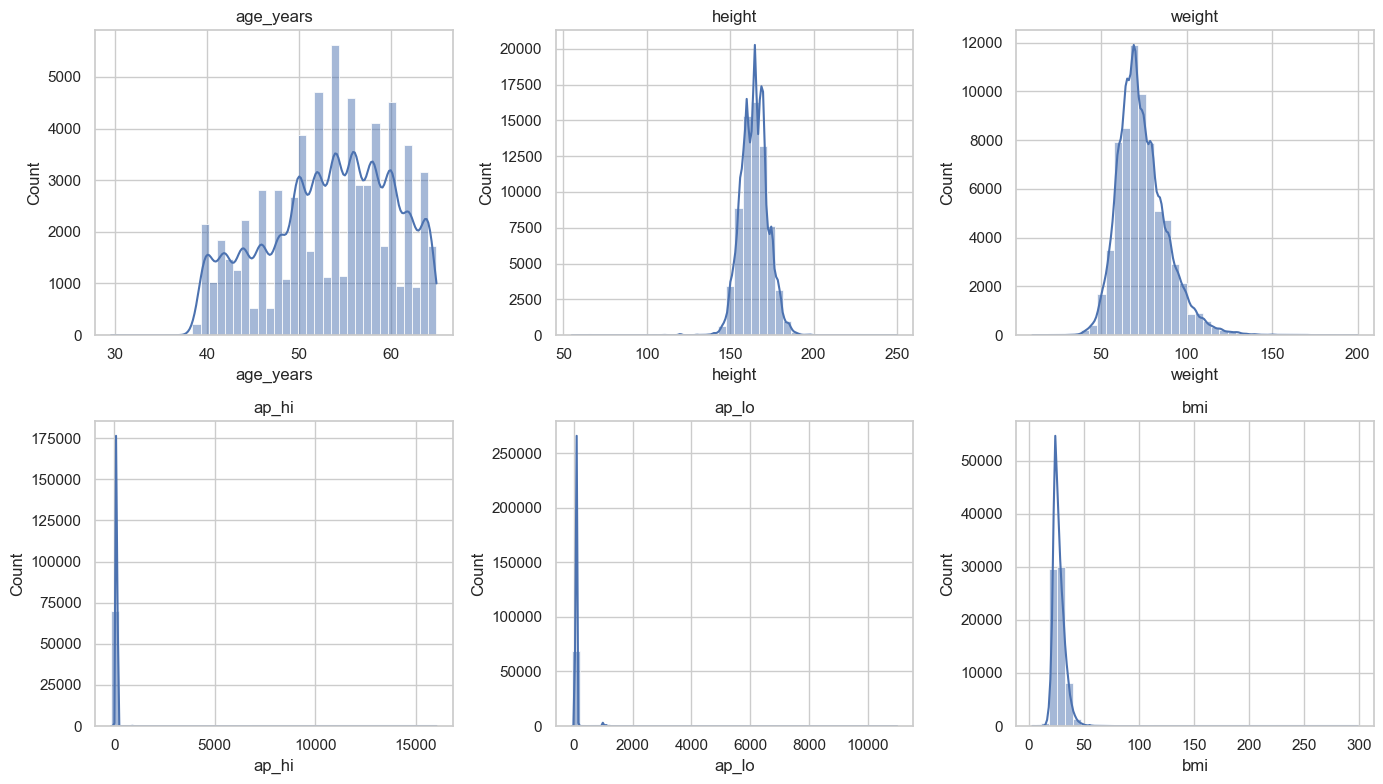

In [3]:
numeric_cols = ["age_years", "height", "weight", "ap_hi", "ap_lo", "bmi"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], ax=ax, bins=40, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Balanceamento do target e de gênero

O dataset é naturalmente equilibrado (~50/50), o que dispensa técnicas de oversampling e torna F1 e accuracy igualmente informativas.

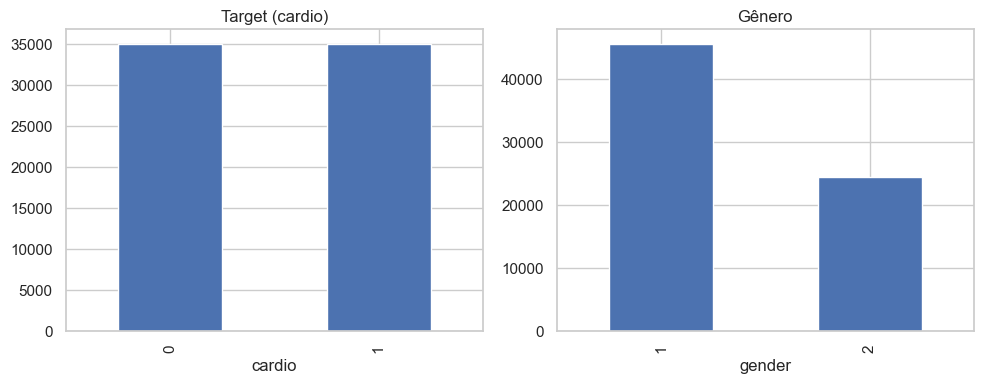

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df[TARGET_COLUMN].value_counts().plot.bar(ax=axes[0], title="Target (cardio)")
df["gender"].value_counts().plot.bar(ax=axes[1], title="Gênero")
plt.tight_layout()
plt.show()

## Matriz de correlação

Revela relacionamento linear entre features numéricas — guia a decisão sobre redução de dimensionalidade (PCA vs LDA).

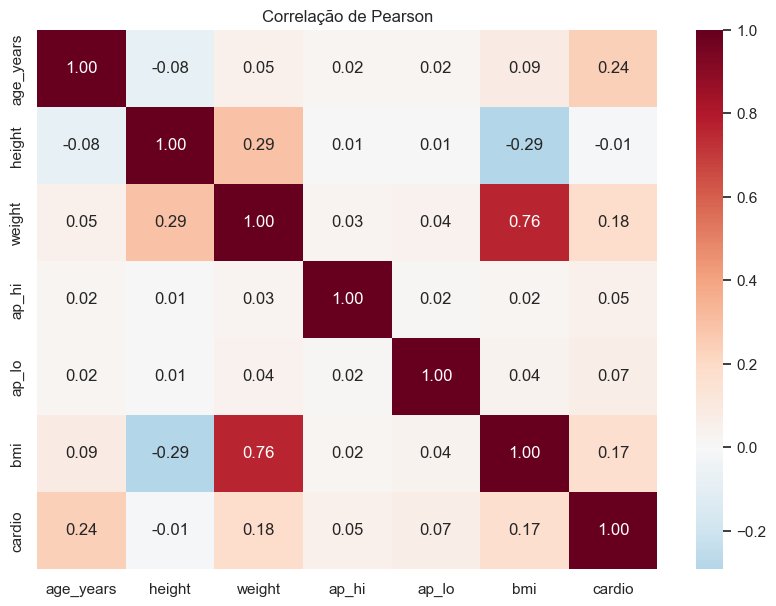

In [5]:
plt.figure(figsize=(10, 7))
corr = df[numeric_cols + [TARGET_COLUMN]].corr()
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlação de Pearson")
plt.show()

## Riscos e limitações estruturais

1. **Outliers fisiológicos em `ap_lo`** (~1000 linhas): indícios de erro de medição/digitação. Tratamento escolhido: **não remover** — o pipeline robustece via scaling, e removê-los poderia introduzir viés de sobrevivência.
2. **Inversões `ap_lo > ap_hi`**: pequenas mas existem. Podem ser sanadas em uma evolução via regra determinística ou flag no modelo.
3. **Features auto-reportadas** (`smoke`, `alco`, `active`): sujeitas a viés social. Esperamos coeficientes de baixa magnitude em modelos lineares.
4. **Sem dados temporais**: o modelo prediz um snapshot, não progressão. Limitação estrutural que deve aparecer na documentação operacional.